## 04. scratchpad

### 1. Data Upload

In [1]:
import pandas as pd
import os
from collections import defaultdict, Counter
import re
import time
from tqdm.notebook import tqdm
import copy

In [2]:
def upload_to_dataframe(root, files, num_lines):
    path_eng, path_pol = [root+f for f in files]
    data = defaultdict(list)
    
    with open (path_eng, encoding="utf_8") as f_eng, open (path_pol, encoding="utf_8") as f_pol:
        for _ in range(num_lines):
            data['eng_text'].append(f_eng.readline().strip())
            data['pol_text'].append(f_pol.readline().strip())
    return pd.DataFrame(data)

In [3]:
root = "../data/opus_opensub/en-pl.txt/"
files = ('OpenSubtitles.en-pl.en', '/OpenSubtitles.en-pl.pl')
df = upload_to_dataframe(root, files, 600000)

### 2. EDA & Sanitazation

#### 2.1 English Non-Ascii Sentences

In [4]:
def nonascii_list(df_series, is_pol):
    if is_pol:
        pl_chars = set("ąęćłńóśźżĄĘĆŁŃÓŚŹŻ")
        requir = lambda x: x.isascii() or x in pl_chars
    else:
        requir = lambda x: x.isascii()
        
    text_all = ''.join(df_series)
    unique_dct = {x for x in text_all if not requir(x)}
    return sorted(list(unique_dct))

In [5]:
print(nonascii_list(df['eng_text'], False))

['\x80', '\x81', '\x82', '\x83', '\x84', '\x85', '\x88', '\x8b', '\x8c', '\x8e', '\x8f', '\x91', '\x94', '\x96', '\x98', '\x99', '\x9c', '\x9d', '\xa0', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '¬', '\xad', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '¼', '½', '¾', '¿', 'Á', 'Â', 'Ã', 'Ä', 'Å', 'Ç', 'É', 'Ê', 'Ì', 'Ï', 'Ð', 'Ñ', 'Ô', 'Ö', 'Ø', 'Ü', 'Ý', 'Þ', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'ç', 'è', 'é', 'ê', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ó', 'ô', 'ö', 'ù', 'ú', 'û', 'ü', 'ý', 'þ', 'Ă', 'ď', 'ę', 'Ł', 'ń', 'ő', 'œ', 'ś', 'Š', 'š', 'Ј', 'С', 'й', '،', 'أ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ح', 'ر', 'س', 'ش', 'ع', 'غ', 'ف', 'ك', 'ل', 'م', 'ن', 'و', 'ي', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', '\u200b', '‒', '–', '—', '‚', '€', '™', '─', '☻', '♥', '♪', '慹', '拢', '檛', '鈥', 'ﬁ', 'ﬂ']


In [6]:
is_ascii = lambda text: text.isascii()
maska = df['eng_text'].apply(is_ascii)
df_non_ascii = df[~maska].copy().reset_index(drop=True)
print(df_non_ascii.shape)
df_non_ascii.head()

(4595, 2)


,eng_text,pol_text
0,¿You had never seen A crab suedes? Them there ...,- Nigdy wcześniej nie widziałaś raków?
1,"He hears ¿, where you live?",Nigdy wcześniej nie byłam w lesie.
2,"Boys ¿, they are there?",Jesteście tam chłopaki?
3,- Te atrapé. - No es gracioso. Your he catches...,- Ale twoje mina była.
4,"Your also ¿, it is not like that?","- Tak, niezła jest"


In [7]:
df_2 = df[maska].reset_index(drop=True)
df_2.shape

(595405, 2)

#### 2.2 Polish Non-Ascii Sentences

In [8]:
pl_chars = set("ąęćłńóśźżĄĘĆŁŃÓŚŹŻ")
requir = lambda let: not let.isascii() and let not in pl_chars
maska = df_2['pol_text'].apply(lambda snt: any([requir(let) for let in snt]))
df_non_ascii = df_2[maska].copy().reset_index(drop=True)
print(df_non_ascii.shape)
df_non_ascii.sample(10)

(1227, 2)


,eng_text,pol_text
781,In the diplomatic gallery are the envoys of tw...,W ložy dyplomatycznej przedstawiciele dwóch pa...
1142,We would drive up the avenue But we haven't go...,¶ Wzięlibyśmy taksówkę ¶ Lecz tu nie ma samochodu
236,- Wait a moment.,– Chwileczkę.
121,"""Let's go, kids - let's move on""","""ChodĽmy, dzieci... przejdĽmy"""
1216,"Is it true, that your family's on friendly ter...","To prawda, że pańska rodzina przyjaźni się z R..."
287,- It's nothing at all.,– Niezupełnie.
435,"- It's been there a long time, sir.",- Jak žywa. Od dawna tam stoi.
206,- I can handle one or two flasks.,– Mogę wypić nawet 2 sho. Wspaniale.
772,"It's a question of my honour, the integrity ...","O uczciwošc komisji, o uczciwosc senatu!"
403,I will not be belittled by my own children.,Nie chce byc ponižany przez wlasne dzieci!


In [9]:
df_3 = df_2[~maska].reset_index(drop=True)
print(df_3.shape)
df_3.sample(5)

(594178, 2)


,eng_text,pol_text
316082,Every nook and cranny in New Orleans.,Przeszukam wszystkie zakamarki w Nowym Orleanie.
11640,"""Nothing.""","""Nic."""
19172,"""Hold on...!""","""Trzymać się...!"""
56079,I'm in the prime of my strength.,Jestem teraz u szczytu mej siły.
478665,Not half as much as you just did.,Znacznie mniej niż pani teraz.


In [10]:
print(nonascii_list(df_3['eng_text'], False))
print(nonascii_list(df_3['pol_text'], True))

[]
[]


In [11]:
df_3.iloc[74182]['eng_text']

'The next time I...'

In [12]:
df_3.iloc[74182]['pol_text']

'Następnym razem...'

#### 2.3 Short Or Empty Examples

In [13]:
mask1 = df_3['eng_text'].str.len() >= 3
mask2 = df_3['pol_text'].str.len() >= 3

In [14]:
df_4 = df_3[mask1 & mask2].reset_index(drop=True)
df_4.head()

,eng_text,pol_text
0,"Previously on ""The Blacklist""...",/W poprzednich odcinkach: /
1,- You want to call your daddy?,- Chcesz zadzwonić do taty?
2,"- Yeah, I want to tell him I'm okay.","- Tak, powiem, że wszystko w porządku."
3,Okay.,Dobrze.
4,Lizzy... Be careful of your husband.,"Lizzy, uważaj na męża."


In [15]:
df_4.shape

(593894, 2)

#### 2.4 Dialog like sentences [starts with - ]

In [16]:
is_dialog = lambda snt: bool(re.match(r"^ *- *", snt))
mask = df_4['eng_text'].apply(is_dialog) | df_4['pol_text'].apply(is_dialog)
df_dialogs = df_4[mask].copy().reset_index(drop=True)
df_dialogs.head()

,eng_text,pol_text
0,- You want to call your daddy?,- Chcesz zadzwonić do taty?
1,"- Yeah, I want to tell him I'm okay.","- Tak, powiem, że wszystko w porządku."
2,- 45 seconds.,Szybciej! 45 sekund.
3,It's okay. It's okay. It's okay.,- Już dobrze.
4,It's okay. You're okay. You're okay.,- Odpoczywaj.


In [17]:
def fix_dialog(snt):
    return re.sub(r"^ *- *", "", snt)

df_4['eng_text'] = df_4['eng_text'].apply(fix_dialog).reset_index(drop=True)
df_4['pol_text'] = df_4['pol_text'].apply(fix_dialog).reset_index(drop=True)
df_4.sample(5)

,eng_text,pol_text
178744,Get your ship ready.,Przygotuj swój statek.
178883,A gigantic mother brooding over her millions o...,"Olbrzymia matka, dumająca nad milionami jej dz..."
166790,"You've got to go now, really.","Musisz już iść, naprawdę."
196423,I've got to be going now.,Muszę iść.
499100,Thank you for your honest opinion.,Dziękuję za szczerą opinię.


#### 2.5 Broken Dialog like sentences [somehwere has -]

# Do naprawy (lepszy re przed tokenziacja)

In [18]:
broken_dialog = lambda snt: bool(re.match(r".* +- +.*", snt))
mask1 = df_4['eng_text'].apply(broken_dialog)
mask2 = df_4['pol_text'].apply(broken_dialog)

In [19]:
df_4[mask1 | mask2].sample(5)

,eng_text,pol_text
186732,Ah-ah-ah-ah-ahh,Ach - ach - ach-ach - ahh
526628,It's on account of all those cows.,To z powodu tych wszystkich krów. - Krów?
492600,"Seven... - We're going to make it, George.",Damy radę.
520917,And don't forget: all guilty. - Even policemen?,I proszę nie zapominać:
185477,"This is Miss Clayton, Dr Bierd.","To jest panna Clayton, doktorze Bierd. - Tak."


In [20]:
df_5 = df_4[~mask1 & ~mask2].reset_index(drop=True)

In [21]:
broken_dialog = lambda snt: bool(re.match(r".*-.*", snt))

In [22]:
df_5.sample(5)

,eng_text,pol_text
180621,"Hartley, you got a bet.",Gdzie ona jest?
433279,See if those toes are okay.,Czy paluszki są całe.
105119,Ask him what became of my sister.,"Zapytaj go, co stało się z moją siostrą."
528693,A refugee?,Uchodźca?
571000,That's what we got.,Do tego doszło.


#### 2.6 Different Last Case

In [23]:
mask = df_5['eng_text'].str[-1] != df_5['pol_text'].str[-1]
mask.sum()

57558

In [24]:
df_6 = df_5[~mask].reset_index(drop=True)

#### 2.7 Text length difference

In [25]:
mask = df_6['eng_text'].str.split
df_6['len_ratio'] = df_6['eng_text'].str.split().str.len() / df_6['pol_text'].str.split().str.len()
df_6.head()

,eng_text,pol_text,len_ratio
0,You want to call your daddy?,Chcesz zadzwonić do taty?,1.500000
1,"Yeah, I want to tell him I'm okay.","Tak, powiem, że wszystko w porządku.",1.333333
2,Okay.,Dobrze.,1.000000
3,Lizzy... Be careful of your husband.,"Lizzy, uważaj na męża.",1.500000
4,I can only lead you to the truth.,/Mogę naprowadzić cię na prawdę.,1.600000


In [26]:
thres_left = df_6["len_ratio"].quantile(0.05)
thres_right = df_6["len_ratio"].quantile(0.95)
thres_left, thres_right

(0.75, 2.5)

In [27]:
mask = (df_6["len_ratio"] >= thres_left) & (df_6["len_ratio"] <= thres_right)
mask.sum()

472209

In [28]:
df_7 = df_6[mask].reset_index(drop=True)
df_7.sample(5)

,eng_text,pol_text,len_ratio
403493,It's Paul.,Paul.,2.000000
265792,Corporal.,Kapralu.,1.000000
365188,"Go away, will you?",Możesz już iść?,1.333333
199811,You humbug!,Ty oszuście!,1.000000
23,Matches hers.,Jest jej.,1.000000


In [29]:
df_7.sample(5)

,eng_text,pol_text,len_ratio
118673,What's that?,I co?,1.00
467237,I've just made a very important discovery.,Właśnie dokonałem bardzo ważnego odkrycia.,1.40
68098,Yeah?,Tak?,1.00
283332,My orders are to collect petrol boats of 30 fe...,"Dostałem rozkaz, żeby ściągnąć... wszystkie ło...",1.75
271493,I wish my nature hadn't changed.,"Szkoda, że musiałem zmienić swoje przyzwyczaje...",1.00


#### 2.8 Sentences starting with * fix

In [30]:
fix_star = lambda snt: re.sub(r"^ *[*].*", "", snt)
df_7['eng_text'] = df_7['eng_text'].apply(fix_star)
df_7['pol_text'] = df_7['pol_text'].apply(fix_star)

#### 2.9 Action Comments

In [31]:
def mask_distinct(df, col1, col2, chars):
    chars_escaped = "".join(re.escape(c) for c in chars)
    templ = f"[{chars_escaped}]"

    m1 = df[col1].str.contains(templ, regex=True, na=False)
    m2 = df[col2].str.contains(templ, regex=True, na=False)

    return m1 ^ m2

chars = '[]()/\*+#$"️'
mask = mask_distinct(df_7, "eng_text", "pol_text", chars)

df_8 = df_7[~mask].reset_index(drop=True)
df_8.shape

(467550, 3)

In [32]:
df_8.sample(5)

,eng_text,pol_text,len_ratio
415457,"Good luck, Danny.","Powodzenia, Danny.",1.5
430031,As you wish.,Jak ojciec chce.,1.0
351356,She would pine away if she went to anybody else.,"Zmarniałaby, gdyby trafiła do obcego.",2.0
323910,"A very reputable man, too, I'm told.","Również szanowany, tak mi mówili.",1.4
138592,Did Colonel Picquart know that by attempting t...,"Później. Czy wiedział, że usiłując uzyskać spr...",1.2


#### 2.10  " ` " ---> " ' " & del " ~ "

In [33]:
wanted_case = '`'
mask = df_8["eng_text"].apply(lambda x: wanted_case in x)
df_8[mask]

,eng_text,pol_text,len_ratio
214145,"Revolution had broken out, her diplomats sued ...","Rewolucja na tyłach frontu, dąży do zawarcia p...",1.277778
214152,We`ll examine it.,Zbadajmy go.,1.500000
214157,What do you think you`re doing?,Wstawaj! Co ty robisz?,1.500000
214161,Where`s your hand grenade?,Gdzie masz swój granat?,1.000000
214163,Let `em have it!,Niech je poczują!,1.333333
...,...,...,...
214943,We don`t want to hate one another.,Bez nienawiści ani pogardy.,1.750000
214944,There`s room for everyone.,Każdy ma swe miejsce.,1.000000
214947,"Greed has poisoned men`s souls, has barricaded...","Chciwość zatruła nasze dusze, wzniosła mury ni...",1.333333
214963,You don`t hate.,Przestańcie nienawidzieć.,1.500000


In [34]:
df_8["eng_text"] = df_8["eng_text"].str.replace("`", "'", regex=False)
df_8["pol_text"] = df_8["pol_text"].str.replace("`", "'", regex=False)

In [35]:
df_8["eng_text"] = df_8["eng_text"].str.replace("~", "", regex=False)
df_8["pol_text"] = df_8["pol_text"].str.replace("~", "", regex=False)

#### 2.11 Del rows with specific case

In [36]:
def del_row_with_char(df, eng_col, pol_col, chars):
    df_proc = df.copy()
    for char in chars:
        mask1 = df_proc[eng_col].apply(lambda x: char in x)
        mask2 = df_proc[pol_col].apply(lambda x: char in x)
        df_proc = df_proc[~(mask1 | mask2)].reset_index(drop=True)
    return df_proc
    

chars = "=+*@#;|_}{"
df_9 = del_row_with_char(df_8, "eng_text", "pol_text", chars)

#### 2.12 Del rows with dialog -

In [37]:
mask1 = df_9["eng_text"].apply(lambda x: bool(re.search(r' +-[^ ]+', x)))
mask2 = df_9["pol_text"].apply(lambda x: bool(re.search(r' +-[^ ]+', x)))
df_data = df_9[~(mask1 | mask2)].reset_index(drop=True)

#### 3. Data Tokenization

In [38]:
uniq_cases = set("".join(df_data["eng_text"].astype(str)))
tab1 = sorted(list(uniq_cases), reverse=True)
print(tab1)

['z', 'y', 'x', 'w', 'v', 'u', 't', 's', 'r', 'q', 'p', 'o', 'n', 'm', 'l', 'k', 'j', 'i', 'h', 'g', 'f', 'e', 'd', 'c', 'b', 'a', ']', '[', 'Z', 'Y', 'X', 'W', 'V', 'U', 'T', 'S', 'R', 'Q', 'P', 'O', 'N', 'M', 'L', 'K', 'J', 'I', 'H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', '?', ':', '9', '8', '7', '6', '5', '4', '3', '2', '1', '0', '/', '.', '-', ',', ')', '(', "'", '%', '$', '"', '!', ' ']


In [39]:
uniq_cases = set("".join(df_data["pol_text"].astype(str)))
tab2 = sorted(list(uniq_cases), reverse=True)
print(tab2)

['ż', 'Ż', 'ź', 'Ź', 'ś', 'Ś', 'ń', 'Ń', 'ł', 'Ł', 'ę', 'Ę', 'ć', 'Ć', 'ą', 'Ą', 'ó', 'Ó', 'z', 'y', 'x', 'w', 'v', 'u', 't', 's', 'r', 'q', 'p', 'o', 'n', 'm', 'l', 'k', 'j', 'i', 'h', 'g', 'f', 'e', 'd', 'c', 'b', 'a', ']', '[', 'Z', 'Y', 'X', 'W', 'V', 'U', 'T', 'S', 'R', 'Q', 'P', 'O', 'N', 'M', 'L', 'K', 'J', 'I', 'H', 'G', 'F', 'E', 'D', 'C', 'B', 'A', '?', ':', '9', '8', '7', '6', '5', '4', '3', '2', '1', '0', '/', '.', '-', ',', ')', '(', "'", '%', '$', '"', '!', ' ']


In [2]:
def tokenize_eng(snt):
    snt = snt.lower()
    snt = re.sub("(?<! )'(?! )", r" '", snt)
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [3]:
def tokenize_pol(snt):
    snt = snt.lower()
    snt = re.sub(r"""([\]?:)\[(/\.\-,%\$"!])""", r" \1 ", snt)
    snt = re.sub(r"\s+", " ", snt).strip()
    return re.split(r'\s+', snt.strip())

In [42]:
df_data = df_data.drop(['len_ratio'], axis=1)

#### 3.1 Splitting and trimming on quantile

In [43]:
df_data['eng_split'] = df_data['eng_text'].apply(tokenize_eng)
df_data['pol_split'] = df_data['pol_text'].apply(tokenize_pol)
df_data.sample(10)

,eng_text,pol_text,eng_split,pol_split
20896,This storm will be magnificent.,Ta burza będzie potężna.,"[this, storm, will, be, magnificent, .]","[ta, burza, będzie, potężna, .]"
193114,You wouldn't feel relieved if I left?,Nie poczułbyś ulgi gdybym wyjechała?,"[you, wouldn, 't, feel, relieved, if, i, left, ?]","[nie, poczułbyś, ulgi, gdybym, wyjechała, ?]"
354192,I'm the funny one.,Ja jestem śmieszna.,"[i, 'm, the, funny, one, .]","[ja, jestem, śmieszna, .]"
269877,"Yes, I wanna see you, right away.","Tak, chcę się z tobą natychmiast zobaczyć.","[yes, ,, i, wanna, see, you, ,, right, away, .]","[tak, ,, chcę, się, z, tobą, natychmiast, zoba..."
222944,"Your Excellency, come! Come quickly! Something...","Wasza ekscelencjo, proszę szybko przyjść.","[your, excellency, ,, come, !, come, quickly, ...","[wasza, ekscelencjo, ,, proszę, szybko, przyjś..."
286845,I do.,Tak.,"[i, do, .]","[tak, .]"
355871,And that's for you.,A to dla ciebie.,"[and, that, 's, for, you, .]","[a, to, dla, ciebie, .]"
108974,"Here's your map, boss.","Twoja mapa, szefie.","[here, 's, your, map, ,, boss, .]","[twoja, mapa, ,, szefie, .]"
392054,All that paperwork wasn't urgent.,Te dokumenty nie były pilne.,"[all, that, paperwork, wasn, 't, urgent, .]","[te, dokumenty, nie, były, pilne, .]"
427647,They're not.,Nie wszystkie.,"[they, 're, not, .]","[nie, wszystkie, .]"


# TODO - zamien lt na It

In [44]:
df_data[df_data['eng_split'].apply(lambda x: 'lt' in x)]

,eng_text,pol_text,eng_split,pol_split
9781,lt was the only thing they had.,"To było jedyne, jakie mieli wolne.","[lt, was, the, only, thing, they, had, .]","[to, było, jedyne, ,, jakie, mieli, wolne, .]"
9811,lt was your fault you put the thing under the ...,"To twoja wina, bo położyłeś go pod łóżko.","[lt, was, your, fault, you, put, the, thing, u...","[to, twoja, wina, ,, bo, położyłeś, go, pod, ł..."
10953,Beat it. lt's a bull!,"Uciekajmy, to gliniarz!","[beat, it, ., lt, 's, a, bull, !]","[uciekajmy, ,, to, gliniarz, !]"
10957,lt went in your pocket.,Wpadł ci do kieszeni.,"[lt, went, in, your, pocket, .]","[wpadł, ci, do, kieszeni, .]"
10981,lt caught in your pocket.,On utknął w kieszeni...,"[lt, caught, in, your, pocket, .]","[on, utknął, w, kieszeni, ., ., .]"
...,...,...,...,...
412362,Okay. lt's your f uneral.,Dobrze. To twój cyrk.,"[okay, ., lt, 's, your, f, uneral, .]","[dobrze, ., to, twój, cyrk, .]"
412366,lt's important.,To ważne.,"[lt, 's, important, .]","[to, ważne, .]"
412439,"Maybe, maybe not. lt's a pretty story.","Może tak, może nie. Niezła historia.","[maybe, ,, maybe, not, ., lt, 's, a, pretty, s...","[może, tak, ,, może, nie, ., niezła, historia, .]"
412454,lt's unlocked.,Jest otwarta.,"[lt, 's, unlocked, .]","[jest, otwarta, .]"


In [45]:
thres1 = df_data['eng_split'].str.len().quantile(0.99)
mask1 = df_data['eng_split'].str.len() > thres1

thres2 = df_data['pol_split'].str.len().quantile(0.99)
mask2 = df_data['pol_split'].str.len() > thres2
print(mask1.sum(), mask2.sum(), (mask1 | mask2).sum())

df_data = df_data[~(mask1 | mask2)].reset_index(drop=True)

4113 3960 5510


#### 3.2 BPE Init. Uniq_freq & Rozklad chars

In [46]:
uniq_freq_eng = Counter(df_data['eng_split'].explode())
uniq_freq_pol = Counter(df_data['pol_split'].explode())

In [47]:
len(uniq_freq_eng), len(uniq_freq_pol)

(40087, 113603)

In [48]:
char_factor = lambda word: [x for x in word] + ['_']
vocab_chars_eng = [[char_factor(k), v] for k, v in uniq_freq_eng.most_common()]
vocab_chars_pol = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common()]
print(len(vocab_chars_eng), vocab_chars_eng[:5], '\n')
print(len(vocab_chars_pol), vocab_chars_pol[:5]) 

40087 [[['.', '_'], 435802], [[',', '_'], 177291], [['y', 'o', 'u', '_'], 134548], [['i', '_'], 122767], [['t', 'h', 'e', '_'], 89859]] 

113603 [[['.', '_'], 413780], [[',', '_'], 183948], [['?', '_'], 83444], [['n', 'i', 'e', '_'], 82694], [['t', 'o', '_'], 53190]]


#### 3.3 BPE Tokenizer

In [4]:
class BPETokenizer():
    def __init__(self, vocab_chrs, vocab_pairs, vocab_size, is_tgt):
        self.vocab_chrs = vocab_chrs
        self.vocab_pairs = vocab_pairs
        self.vocab_size = vocab_size
        self.pair_counts = self.pair_counts_init(vocab_pairs)
        self.vocab = self.vocab_init(vocab_chrs, is_tgt)
        self.base_size = len(self.vocab)

    def vocab_init(self, vocab_chrs, is_tgt):
        vocab = {'<pad>': 0, '<unk>': 1, '<eos>': 2, '_': 3}
        if is_tgt:
            vocab['<bos>'] = 4
            
        uniq_toks = {tok for toks, _ in vocab_chrs for tok in toks}
        uniq_toks.remove('_')
        for i, tok in enumerate(uniq_toks, len(vocab)):
            vocab[tok] = i
        return vocab

    def pair_counts_init(self, vocab_pairs):
        pair_counts = defaultdict(int)
        for toks, freq in vocab_pairs:
            for pair in toks:
                pair_counts[pair] += freq
        return pair_counts

    def train_bpe(self):
        for i in tqdm(range(self.base_size, self.vocab_size)):
            pair = self.most_common_pair()
            self.vocab[pair] = i
            self.replace_pairs(pair)

    def replace_pairs(self, pair):
        pair_con = f"{pair[0]}{pair[1]}"
        p_1, p_2 = map(re.escape, pair)
        
        for i in range(len(self.vocab_chrs)):
            if pair in self.vocab_pairs[i][0]:
                new_chr = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", pair_con, f" {' '.join(self.vocab_chrs[i][0])} ").split()
                self.vocab_chrs[i][0] = new_chr
                self.update_pair_count(list(zip(new_chr, new_chr[1:])), i)
        self.pair_counts.pop(pair)

    def update_pair_count(self, new_pairs, i):
        old_pairs, val = self.vocab_pairs[i]
        for tup in old_pairs:
            self.pair_counts[tup] -= val  
        for tup in new_pairs:
            self.pair_counts[tup] += val
        self.vocab_pairs[i][0] = new_pairs
      
    def most_common_pair(self):
        return max(self.pair_counts, key=self.pair_counts.get)

In [54]:
vocab_test1 = [[char_factor(k), v] for k, v in uniq_freq_eng.most_common()]
pair_vocab1= [[list(zip(tab, tab[1:])), v] for tab, v in vocab_test1]
tokenizer_test1 = BPETokenizer(vocab_test1, pair_vocab1, 8000, False)

t = time.time()
tokenizer_test1.train_bpe()
print(f"{time.time()-t:.2f} seconds")

  0%|          | 0/7945 [00:00<?, ?it/s]

176.00 seconds


In [192]:
vocab_test2 = [[char_factor(k), v] for k, v in uniq_freq_pol.most_common() if v > 1]
pair_vocab2 = [[list(zip(tab, tab[1:])), v] for tab, v in vocab_test2]
tokenizer_test2 = BPETokenizer(vocab_test2, pair_vocab2, 16000, True)

t = time.time()
tokenizer_test2.train_bpe()
print(f"{time.time()-t:.2f} seconds")

  0%|          | 0/15935 [00:00<?, ?it/s]

677.41 seconds


In [204]:
tokenizer_test2.vocab

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 'a': 5,
 ']': 6,
 '%': 7,
 '1': 8,
 '5': 9,
 '7': 10,
 'b': 11,
 '?': 12,
 'ś': 13,
 'ż': 14,
 '8': 15,
 '/': 16,
 'm': 17,
 'u': 18,
 's': 19,
 '6': 20,
 '.': 21,
 'c': 22,
 'ń': 23,
 '0': 24,
 ':': 25,
 'ć': 26,
 'ó': 27,
 '!': 28,
 '3': 29,
 'f': 30,
 'x': 31,
 'ę': 32,
 'ą': 33,
 '4': 34,
 '(': 35,
 '"': 36,
 'r': 37,
 ',': 38,
 'n': 39,
 '9': 40,
 'o': 41,
 'ł': 42,
 '$': 43,
 '-': 44,
 'v': 45,
 '[': 46,
 'j': 47,
 'd': 48,
 'y': 49,
 'k': 50,
 'e': 51,
 'h': 52,
 'z': 53,
 'q': 54,
 '2': 55,
 't': 56,
 "'": 57,
 'ź': 58,
 'i': 59,
 'g': 60,
 'p': 61,
 'l': 62,
 'w': 63,
 ')': 64,
 ('.', '_'): 65,
 ('i', 'e'): 66,
 ('o', '_'): 67,
 ('a', '_'): 68,
 ('ie', '_'): 69,
 (',', '_'): 70,
 ('y', '_'): 71,
 ('e', '_'): 72,
 ('i', '_'): 73,
 ('ę', '_'): 74,
 ('m', '_'): 75,
 ('n', 'ie_'): 76,
 ('s', 'z'): 77,
 ('s', 't'): 78,
 ('d', 'z'): 79,
 ('c', 'z'): 80,
 ('r', 'z'): 81,
 ('p', 'o'): 82,
 ('c', 'h'): 83,
 ('?', '_'): 84,
 

#### 3.4 BPE Encoder 

In [72]:
class BPEEncoder():
    def __init__(self, bpe_vocab, thres_tup=55, is_tgt=False):
        self.vocab_encoder = {"".join(k): v for k, v in bpe_vocab.items()}
        self.vocab_tuple = list(bpe_vocab.keys())[thres_tup:]

        self.tokenize = tokenize_pol if is_tgt else tokenize_eng
        self.char_factor = lambda word: list(word) + ['_']

    def encode_snt(self, snt):
        return [y for x in self.tokenize(snt) for y in self.encode_word(x)]

    def encode_word(self, word):
        word_factor = self.char_factor(word)
        word_id = self.vocab_encoder.get("".join(word_factor), None)
        if word_id:
            yield from [word_id]
        else:
            word_pairs = list(zip(word_factor, word_factor[1:]))
            for pair in self.vocab_tuple:
                if pair in word_pairs:
                    p_1, p_2 = map(re.escape, pair)
                    word_factor = re.sub(rf"(?<=\s){p_1}\s{p_2}(?=\s)", f"{pair[0]}{pair[1]}", f" {' '.join(word_factor)} ").split()
                    word_pairs = list(zip(word_factor, word_factor[1:]))
            yield from [self.vocab_encoder[x] for x in word_factor]

In [197]:
test_encoder1 = BPEEncoder(tokenizer_test1.vocab)
test_dct1 = {v: k for k, v in test_encoder1.vocab_encoder.items()}

In [233]:
test_tab1 = []
tab1 = test_encoder1.encode_snt("Wow, that means so much.")
for x in tab1:
    test_tab1.append(test_dct1[x])
print(test_tab1)

['wow_', ',_', 'that_', 'means_', 'so_', 'much_', '._']


In [205]:
test_encoder2 = BPEEncoder(tokenizer_test2.vocab, 65, True)
test_dct2 = {v: k for k, v in test_encoder2.vocab_encoder.items()}

In [221]:
[test_dct2[x] for x in test_encoder2.encode_word("biegną")]

['bieg', 'ną_']

In [212]:
test_tab2 = []
tab2 = test_encoder2.encode_snt("Mam nadzieję, że spotka ciebie surowa kara.")
for x in tab2:
    test_tab2.append(test_dct2[x])
print(test_tab2)

['mam_', 'nadzieję_', ',_', 'że_', 'spotka_', 'ciebie_', 'suro', 'wa_', 'kara_', '._']


#### 3.5 Encoding eng examples

In [229]:
encoder_eng = BPEEncoder(tokenizer_test1.vocab)
test_encoder_eng = {v: k for k, v in encoder_eng.vocab_encoder.items()}

In [227]:
data_eng = df_data[['eng_text', 'eng_split']].reset_index(drop=True)
data_eng.head()

,eng_text,eng_split
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]"
2,Okay.,"[okay, .]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,..."


In [234]:
data_eng['eng_ids'] = data_eng['eng_text'].apply(encoder_eng.encode_snt)
data_eng.head()

,eng_text,eng_split,eng_ids
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]","[69, 269, 80, 615, 161, 2309, 77]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,..."
2,Okay.,"[okay, .]","[947, 56]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9..."


#### 3.6 Encoding pol examples

In [237]:
encoder_pol = BPEEncoder(tokenizer_test2.vocab, 65, True)
test_encoder_pol = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [228]:
data_pol = df_data[['pol_text', 'pol_split']].reset_index(drop=True)
data_pol.head()

,pol_text,pol_split
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]"
2,Dobrze.,"[dobrze, .]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t..."


In [238]:
data_pol['pol_ids'] = data_pol['pol_text'].apply(encoder_pol.encode_snt)
data_pol.head()

,pol_text,pol_split,pol_ids
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]","[472, 4187, 140, 6512, 84]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[133, 70, 913, 70, 116, 350, 103, 617, 65]"
2,Dobrze.,"[dobrze, .]","[327, 65]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]","[3902, 2243, 70, 2051, 101, 2150, 65]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29..."


#### Zapis klas to bpe tokenizera

In [6]:
import pickle

In [240]:
# # zapis
# with open('tokenizer_eng.pkl', 'wb') as f:
#     pickle.dump(tokenizer_eng, f)

# # odczyt
# with open('tokenizer_eng.pkl', 'rb') as f:
#     tokenizer_eng = pickle.load(f)

In [243]:
with open("../data/bpe_tokenizer_eng.pkl", 'wb') as f:
    pickle.dump(tokenizer_test1, f)

In [247]:
with open("../data/dataframe_eng.pkl", 'wb') as f:
    pickle.dump(data_eng, f)

In [244]:
with open("../data/bpe_tokenizer_pol.pkl", 'wb') as f:
    pickle.dump(tokenizer_test2, f)

In [ ]:
with open("../data/dataframe_pol.pkl", 'wb') as f:
    pickle.dump(data_pol, f)

#### Odczyt klas i df'ów

In [7]:
with open("../data/bpe_tokenizer_eng.pkl", 'rb') as f:
    tokenizer_eng = pickle.load(f)

In [8]:
with open("../data/dataframe_eng.pkl", 'rb') as f:
    data_eng = pickle.load(f)

In [9]:
with open("../data/bpe_tokenizer_pol.pkl", 'rb') as f:
    tokenizer_pol = pickle.load(f)

In [10]:
with open("../data/dataframe_pol.pkl", 'rb') as f:
    data_pol = pickle.load(f)

#### 32948. Blagam per chance...

In [122]:
tokenizer_pol.vocab

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 'a': 5,
 ']': 6,
 '%': 7,
 '1': 8,
 '5': 9,
 '7': 10,
 'b': 11,
 '?': 12,
 'ś': 13,
 'ż': 14,
 '8': 15,
 '/': 16,
 'm': 17,
 'u': 18,
 's': 19,
 '6': 20,
 '.': 21,
 'c': 22,
 'ń': 23,
 '0': 24,
 ':': 25,
 'ć': 26,
 'ó': 27,
 '!': 28,
 '3': 29,
 'f': 30,
 'x': 31,
 'ę': 32,
 'ą': 33,
 '4': 34,
 '(': 35,
 '"': 36,
 'r': 37,
 ',': 38,
 'n': 39,
 '9': 40,
 'o': 41,
 'ł': 42,
 '$': 43,
 '-': 44,
 'v': 45,
 '[': 46,
 'j': 47,
 'd': 48,
 'y': 49,
 'k': 50,
 'e': 51,
 'h': 52,
 'z': 53,
 'q': 54,
 '2': 55,
 't': 56,
 "'": 57,
 'ź': 58,
 'i': 59,
 'g': 60,
 'p': 61,
 'l': 62,
 'w': 63,
 ')': 64,
 ('.', '_'): 65,
 ('i', 'e'): 66,
 ('o', '_'): 67,
 ('a', '_'): 68,
 ('ie', '_'): 69,
 (',', '_'): 70,
 ('y', '_'): 71,
 ('e', '_'): 72,
 ('i', '_'): 73,
 ('ę', '_'): 74,
 ('m', '_'): 75,
 ('n', 'ie_'): 76,
 ('s', 'z'): 77,
 ('s', 't'): 78,
 ('d', 'z'): 79,
 ('c', 'z'): 80,
 ('r', 'z'): 81,
 ('p', 'o'): 82,
 ('c', 'h'): 83,
 ('?', '_'): 84,
 

In [121]:
data_eng.head()

,eng_text,eng_split,eng_ids,eng_ids_2
0,You want to call your daddy?,"[you, want, to, call, your, daddy, ?]","[69, 269, 80, 615, 161, 2309, 77]","[69, 269, 80, 615, 161, 2309, 77, 2]"
1,"Yeah, I want to tell him I'm okay.","[yeah, ,, i, want, to, tell, him, i, 'm, okay, .]","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,...","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,..."
2,Okay.,"[okay, .]","[947, 56]","[947, 56, 2]"
3,Lizzy... Be careful of your husband.,"[lizzy, ., ., ., be, careful, of, your, husban...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9...","[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9..."
4,"Elizabeth Keen is not your wife, she's your ta...","[elizabeth, keen, is, not, your, wife, ,, she,...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9..."


In [120]:
data_eng['eng_ids_2'] = data_eng['eng_ids'].apply(lambda x: x + [2])

In [12]:
data_pol.head()

,pol_text,pol_split,pol_ids
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]","[472, 4187, 140, 6512, 84]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[133, 70, 913, 70, 116, 350, 103, 617, 65]"
2,Dobrze.,"[dobrze, .]","[327, 65]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]","[3902, 2243, 70, 2051, 101, 2150, 65]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29..."


In [124]:
data_pol['pol_ids_2'] = data_pol['pol_ids'].apply(lambda x: [4] + x + [2])
data_pol.head()

,pol_text,pol_split,pol_ids,pol_ids_2
0,Chcesz zadzwonić do taty?,"[chcesz, zadzwonić, do, taty, ?]","[472, 4187, 140, 6512, 84]","[4, 472, 4187, 140, 6512, 84, 2]"
1,"Tak, powiem, że wszystko w porządku.","[tak, ,, powiem, ,, że, wszystko, w, porządku, .]","[133, 70, 913, 70, 116, 350, 103, 617, 65]","[4, 133, 70, 913, 70, 116, 350, 103, 617, 65, 2]"
2,Dobrze.,"[dobrze, .]","[327, 65]","[4, 327, 65, 2]"
3,"Lizzy, uważaj na męża.","[lizzy, ,, uważaj, na, męża, .]","[3902, 2243, 70, 2051, 101, 2150, 65]","[4, 3902, 2243, 70, 2051, 101, 2150, 65, 2]"
4,"Elizabeth Keen nie jest twoją żoną, tylko celem.","[elizabeth, keen, nie, jest, twoją, żoną, ,, t...","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29...","[4, 5402, 1567, 2351, 76, 134, 1556, 2586, 70,..."


In [13]:
df_final = pd.concat([data_eng, data_pol], axis=1)[['eng_text', 'eng_ids', 'pol_text', 'pol_ids']]
df_final.head()

,eng_text,eng_ids,pol_text,pol_ids
0,You want to call your daddy?,"[69, 269, 80, 615, 161, 2309, 77]",Chcesz zadzwonić do taty?,"[472, 4187, 140, 6512, 84]"
1,"Yeah, I want to tell him I'm okay.","[448, 63, 70, 269, 80, 311, 197, 70, 173, 947,...","Tak, powiem, że wszystko w porządku.","[133, 70, 913, 70, 116, 350, 103, 617, 65]"
2,Okay.,"[947, 56]",Dobrze.,"[327, 65]"
3,Lizzy... Be careful of your husband.,"[1758, 993, 56, 56, 56, 148, 1512, 111, 161, 9...","Lizzy, uważaj na męża.","[3902, 2243, 70, 2051, 101, 2150, 65]"
4,"Elizabeth Keen is not your wife, she's your ta...","[3489, 888, 110, 93, 184, 161, 781, 63, 226, 9...","Elizabeth Keen nie jest twoją żoną, tylko celem.","[5402, 1567, 2351, 76, 134, 1556, 2586, 70, 29..."


In [36]:
thres1 = df_final['eng_ids'].str.len().quantile(0.99)
mask1 = df_final['eng_ids'].str.len() > thres1

thres2 = df_final['pol_ids'].str.len().quantile(0.99)
mask2 = df_final['pol_ids'].str.len() > thres2
print(mask1.sum(), mask2.sum(), (mask1 | mask2).sum())

df_final = df_final[~(mask1 | mask2)].reset_index(drop=True)

3887 3574 5780


In [40]:
train_df, val_df = Data.shuffle_split(df_final, 0.9)

In [41]:
train_df.shape, val_df.shape

((409406, 4), (45490, 4))

In [44]:
val_df.head()

,eng_text,eng_ids,pol_text,pol_ids
0,And then Stefania left home.,"[100, 381, 6460, 692, 522, 56]",A potem Stefania opuściła dom.,"[68, 963, 11096, 12552, 1165, 65]"
1,You said an odd thing just now.,"[69, 482, 115, 3461, 180, 237, 132, 56]",Przed chwilą powiedziałeś coś dziwnego.,"[740, 6100, 1700, 341, 4464, 65]"
2,You can't be that in business.,"[69, 177, 97, 148, 105, 102, 765, 56]",W biznesie nie ma na to miejsca.,"[103, 11054, 76, 229, 101, 94, 2011, 65]"
3,"I don't want no trouble with you, mister.","[70, 162, 97, 269, 170, 870, 181, 69, 63, 2110...",Nie chcę żadnych kłopotów facet.,"[76, 415, 1660, 2940, 1610, 65]"
4,Au Revoir.,"[5686, 6728, 56]",Do widzenia.,"[140, 1489, 65]"


In [55]:
import Data

In [56]:
train_data = Data.EngPolDataset(train_df, 'eng_ids', 'pol_ids')
val_data = Data.EngPolDataset(val_df, 'eng_ids', 'pol_ids')

In [59]:
train_data.__getitem__(4)

(tensor([128,  92,  85, 228,  77]), tensor([ 67, 753,  94, 134,  84]))

# 6. TRAINING zapomniales dodac <eos>

In [60]:
import Model
import Trainer

In [67]:
len(tokenizer_eng.vocab), len(tokenizer_pol.vocab)

(8000, 16000)

In [69]:
num_hiddens, num_blks, dropout = 256, 2, 0.2
ffn_num_hiddens, num_heads = 512, 4

encoder = Model.TransformerEncoder(8000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
decoder = Model.TransformerDecoder(16000, num_hiddens, ffn_num_hiddens, num_heads, num_blks, dropout)
model = Model.Seq2Seq(encoder=encoder, decoder=decoder, lr=0.001, pad_id=0, device='cuda')

In [70]:
trainer = Trainer.TrainerModule(batch_size=64)
trainer.plotter_init("Test BPE eun nr.1")

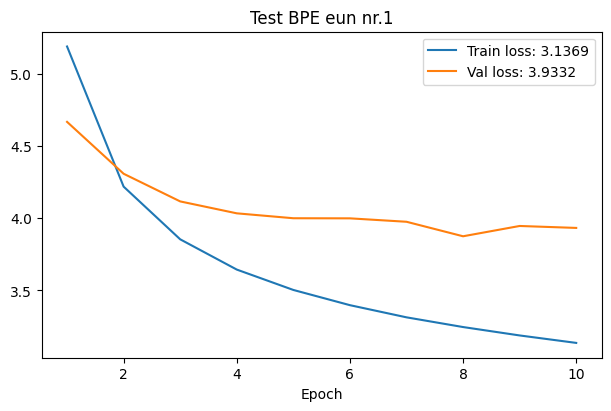

In [71]:
trainer.fit(model, train_data, val_data, 10, '../checkpoints/checkpoint_bpe1.pt')

# 7. Prediction

In [100]:
encoder_eng = BPEEncoder(tokenizer_eng.vocab)
encoder_pol = BPEEncoder(tokenizer_pol.vocab, 65, True)
rev_pol_encoder = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [101]:
snt_eng = "I love you."
snt_ids = encoder_eng.encode_snt(snt_eng)
enc_X = torch.tensor(snt_ids).reshape(1, -1).to("cuda")
enc_valid_len = torch.tensor([len(snt_ids)]).reshape(-1, 1).to("cuda")
enc_X, enc_valid_len

(tensor([[ 70, 466,  69,  56]], device='cuda:0'),
 tensor([[4]], device='cuda:0'))

In [102]:
def predict_step(snt_eng, model, max_len=34):
    device = model.device
    snt_ids = encoder_eng.encode_snt(snt_eng)
    
    src_eng = torch.tensor(snt_ids).reshape(1, -1).to(device)
    src_len = torch.tensor([len(snt_ids)]).reshape(-1, 1).to(device)
    
    bos_id, eos_id = tokenizer_pol.vocab['<bos>'], tokenizer_pol.vocab['<eos>']
    
    with torch.no_grad():
        model.eval()
        X_enc = model.encoder(src_eng, src_len)
        dec_state = model.decoder.init_state(X_enc, src_len)
        pred_ids = [torch.tensor(bos_id).reshape(1, -1).to(device)]

        for _ in range(max_len):
            Y_dec, dec_state = model.decoder(pred_ids[-1], dec_state)
            pred_ids.append(Y_dec.argmax(2))
            if pred_ids[-1].item() == eos_id:
                break
    return [rev_pol_encoder[x.item()] for x in pred_ids]

In [117]:
tab = predict_step("Fuck.", model)
print(tab)

['<bos>', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._', '._']


In [99]:
rev_pol_encoder = {v: k for k, v in encoder_pol.vocab_encoder.items()}

In [94]:
encoder_pol.vocab_encoder

{'<pad>': 0,
 '<unk>': 1,
 '<eos>': 2,
 '_': 3,
 '<bos>': 4,
 'a': 5,
 ']': 6,
 '%': 7,
 '1': 8,
 '5': 9,
 '7': 10,
 'b': 11,
 '?': 12,
 'ś': 13,
 'ż': 14,
 '8': 15,
 '/': 16,
 'm': 17,
 'u': 18,
 's': 19,
 '6': 20,
 '.': 21,
 'c': 22,
 'ń': 23,
 '0': 24,
 ':': 25,
 'ć': 26,
 'ó': 27,
 '!': 28,
 '3': 29,
 'f': 30,
 'x': 31,
 'ę': 32,
 'ą': 33,
 '4': 34,
 '(': 35,
 '"': 36,
 'r': 37,
 ',': 38,
 'n': 39,
 '9': 40,
 'o': 41,
 'ł': 42,
 '$': 43,
 '-': 44,
 'v': 45,
 '[': 46,
 'j': 47,
 'd': 48,
 'y': 49,
 'k': 50,
 'e': 51,
 'h': 52,
 'z': 53,
 'q': 54,
 '2': 55,
 't': 56,
 "'": 57,
 'ź': 58,
 'i': 59,
 'g': 60,
 'p': 61,
 'l': 62,
 'w': 63,
 ')': 64,
 '._': 65,
 'ie': 66,
 'o_': 67,
 'a_': 68,
 'ie_': 69,
 ',_': 70,
 'y_': 71,
 'e_': 72,
 'i_': 73,
 'ę_': 74,
 'm_': 75,
 'nie_': 76,
 'sz': 77,
 'st': 78,
 'dz': 79,
 'cz': 80,
 'rz': 81,
 'po': 82,
 'ch': 83,
 '?_': 84,
 'je': 85,
 'ć_': 86,
 'an': 87,
 'si': 88,
 'ał': 89,
 'ak': 90,
 'ro': 91,
 'ra': 92,
 'j_': 93,
 'to_': 94,
 'u_': 95,